<a href="https://colab.research.google.com/github/Pranjli-S/Assignment_T20-EDA-/blob/main/T20_EDA_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Top 3 Venues:
venue
Dubai International Cricket Stadium    62
Sheikh Zayed Stadium                   41
Shere Bangla National Stadium          39
Name: count, dtype: int64 

Most Frequent Matchup:
team_pair
(Australia, England)    45
Name: count, dtype: int64 

Top 5 Teams by Win Percentage:


,played,won,win_pct
Belgium,3,3,100.000000
Spain,6,5,83.333333
Germany,17,13,76.470588
Namibia,34,25,73.529412
Afghanistan,75,51,68.000000


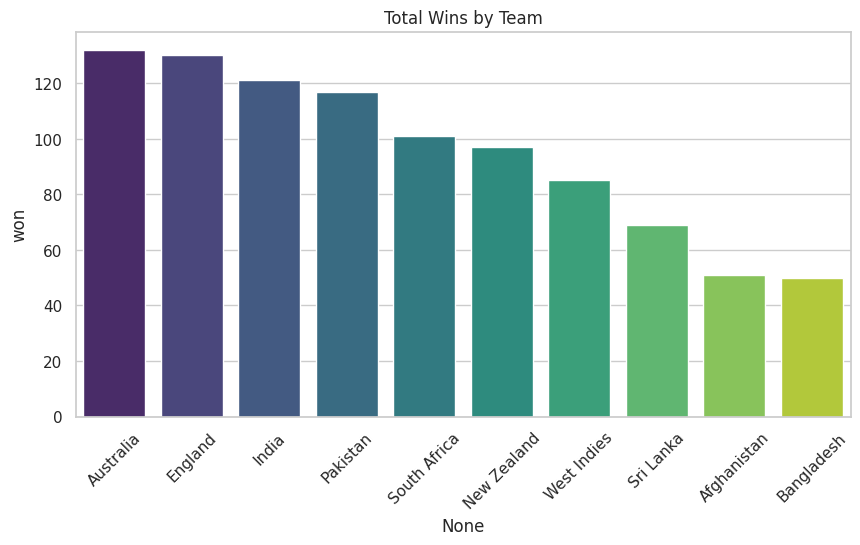

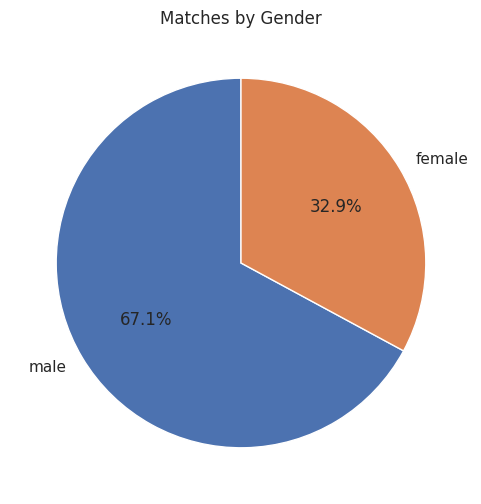


--- 1st Innings Scorecard ---


,Batsman,Runs,Bowler,Wkts,Runs_Con
0,AJ Finch,43,SL Malinga,2,29
1,M Klinger,38,JRMVB Sanjaya,1,35
2,TM Head,31,DAS Gunaratne,1,11
3,AJ Turner,18,PADLR Sandakan,1,31



--- 2nd Innings Scorecard ---


,Batsman,Runs,Bowler,Wkts,Runs_Con
0,DAS Gunaratne,52,A Zampa,2,26
1,EMDY Munaweera,44,AJ Turner,2,12
2,N Dickwella,30,PJ Cummins,1,30
3,TAM Siriwardana,15,B Stanlake,0,42


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('International_T20_Data.csv')

df = df.rename(columns={
    'info.venue': 'venue',
    'info.teams': 'teams',
    'info.outcome.winner': 'winner',
    'info.outcome.by.runs': 'win_by_runs',
    'info.gender': 'gender',
    'info.overs': 'overs'
})

top_venues = df['venue'].value_counts().head(3)
print("Top 3 Venues:")
print(top_venues, "\n")

df['teams_list'] = df['teams'].apply(eval)
df['team_pair'] = df['teams_list'].apply(lambda x: tuple(sorted(x)))
top_pair = df['team_pair'].value_counts().head(1)
print("Most Frequent Matchup:")
print(top_pair, "\n")

team_stats = {}
for idx, row in df.iterrows():
    teams = row['teams_list']
    winner = row['winner']
    for team in teams:
        if team not in team_stats:
            team_stats[team] = {'played': 0, 'won': 0}
        team_stats[team]['played'] += 1
        if pd.notna(winner) and team == winner:
            team_stats[team]['won'] += 1

stats_df = pd.DataFrame.from_dict(team_stats, orient='index')
stats_df['win_pct'] = (stats_df['won'] / stats_df['played']) * 100
top_5_teams = stats_df.sort_values(by='win_pct', ascending=False).head(5)
print("Top 5 Teams by Win Percentage:")
display(top_5_teams)

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 5))
top_10_wins = stats_df.sort_values(by='won', ascending=False).head(10)
sns.barplot(x=top_10_wins.index, y=top_10_wins['won'], hue=top_10_wins.index, palette="viridis", legend=False)
plt.title("Total Wins by Team")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(6, 6))
gender_counts = df['gender'].value_counts()
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90)
plt.title("Matches by Gender")
plt.show()

def get_scorecard(match_index):
    innings_list = eval(df['innings'][match_index])
    scorecards = []

    for inning_label in ['1st innings', '2nd innings']:
        found_data = None
        for item in innings_list:
            if inning_label in item:
                found_data = item[inning_label]

        if found_data is None:
            scorecards.append(pd.DataFrame())
            continue

        deliveries = found_data['deliveries']
        batsmen = {}
        bowlers = {}

        for d in deliveries:
            details = list(d.values())[0]
            bat_name = details['batsman']
            bowl_name = details['bowler']
            runs = details['runs']['batsman']
            total_runs = details['runs']['total']

            batsmen[bat_name] = batsmen.get(bat_name, 0) + runs

            if bowl_name not in bowlers:
                bowlers[bowl_name] = {'Wickets': 0, 'Runs': 0}
            bowlers[bowl_name]['Runs'] += total_runs

            if 'wicket' in details:
                if details['wicket']['kind'] != 'run out':
                    bowlers[bowl_name]['Wickets'] += 1

        df_bat = pd.DataFrame(list(batsmen.items()), columns=['Batsman', 'Runs'])
        df_bat = df_bat.sort_values('Runs', ascending=False).head(4).reset_index(drop=True)

        df_bowl = pd.DataFrame([{'Bowler': k, 'Wkts': v['Wickets'], 'Runs_Con': v['Runs']} for k, v in bowlers.items()])
        df_bowl = df_bowl.sort_values('Wkts', ascending=False).head(4).reset_index(drop=True)

        combined = pd.concat([df_bat, df_bowl], axis=1)
        scorecards.append(combined)

    return scorecards[0], scorecards[1]

inning1, inning2 = get_scorecard(0)
print("\n--- 1st Innings Scorecard ---")
display(inning1)
print("\n--- 2nd Innings Scorecard ---")
display(inning2)